## 1. Library Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Plotting defaults ──
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Set2")

CHURN_COLORS = {0: '#2196F3', 1: '#F44336'}   # blue = retained, red = churned
print("Libraries loaded successfully.")


Libraries loaded successfully.


**📌 Insight — Libraries:**
All core data science libraries are loaded. `matplotlib` and `seaborn` are configured with spine suppression and a consistent colour palette. Churned customers will be highlighted in red throughout, retained in blue — making every chart immediately readable at a glance.

## 2. Data Loading

In [3]:
# ── Load Datasets ──
client_df = pd.read_csv('client_data.csv')
price_df  = pd.read_csv('price_data.csv')

print("── Client Data ──")
print(f"  Shape : {client_df.shape[0]:,} rows × {client_df.shape[1]} columns")
print()
print("── Price Data ──")
print(f"  Shape : {price_df.shape[0]:,} rows × {price_df.shape[1]} columns")


── Client Data ──
  Shape : 14,606 rows × 26 columns

── Price Data ──
  Shape : 193,002 rows × 8 columns


**📌 Insight — Dataset Scale:**
- **Client data** contains 14,606 unique customers across 26 features — a rich dataset for profiling.
- **Price data** contains 193,002 records — approximately 13 months of monthly pricing per customer (~13,223 unique customers have pricing data).
- The two datasets link via the `id` field, enabling us to enrich the customer profile with historical pricing behaviour.

In [4]:
# ── Quick Previews ──
print("Client Data — First 3 rows:")
client_df.head(3)


Client Data — First 3 rows:


,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.0,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.0,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.0,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0


**📌 Insight — Client Data Preview:**
The dataset contains a mix of numeric consumption/margin columns, date columns (stored as strings — will need conversion), and categorical identifiers like `channel_sales` and `origin_up`. The `churn` column (0/1) is our target variable. The encoded column names suggest anonymisation of sensitive channel and origin data by the client.

In [4]:
print("Price Data — First 3 rows:")
price_df.head(3)


Price Data — First 3 rows:


,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0


**📌 Insight — Price Data Preview:**
The price data is in long format — one row per customer per month. Most mid-peak and peak prices appear to be zero, suggesting the majority of customers are on simple off-peak tariffs. The `price_off_peak_var` and `price_off_peak_fix` columns will therefore be the most analytically meaningful pricing variables.

## 3. Data Understanding

### 3.1 Column Descriptions

**Client Data** (one row per customer):

| Column | Description |
|--------|-------------|
| `id` | Unique customer identifier |
| `channel_sales` | Sales channel through which customer was acquired |
| `cons_12m` | Electricity consumption in the past 12 months (kWh) |
| `cons_gas_12m` | Gas consumption in the past 12 months |
| `cons_last_month` | Electricity consumption last month |
| `date_activ` | Date customer contract was activated |
| `date_end` | Scheduled contract end date |
| `date_modif_prod` | Last product modification date |
| `date_renewal` | Contract renewal date |
| `forecast_cons_12m` | Forecasted electricity consumption next 12 months |
| `forecast_discount_energy` | Forecasted energy discount |
| `forecast_price_energy_off_peak` | Forecasted off-peak energy price |
| `forecast_price_energy_peak` | Forecasted peak energy price |
| `forecast_price_pow_off_peak` | Forecasted off-peak power price |
| `has_gas` | Whether customer has a gas contract (t/f) |
| `imp_cons` | Importance of consumption |
| `margin_gross_pow_ele` | Gross margin on electricity power |
| `margin_net_pow_ele` | Net margin on electricity power |
| `nb_prod_act` | Number of active products |
| `net_margin` | Overall net margin |
| `num_years_antig` | Customer tenure (years) |
| `origin_up` | Origin channel of customer's latest upgrade |
| `pow_max` | Maximum contracted power |
| `churn` | **Target variable** — 1 = churned, 0 = retained |

**Price Data** (one row per customer per month):

| Column | Description |
|--------|-------------|
| `id` | Customer identifier (links to client data) |
| `price_date` | Month of pricing record (Jan–Dec 2015) |
| `price_off_peak_var` | Variable off-peak energy price |
| `price_peak_var` | Variable peak energy price |
| `price_mid_peak_var` | Variable mid-peak energy price |
| `price_off_peak_fix` | Fixed off-peak power price |
| `price_peak_fix` | Fixed peak power price |
| `price_mid_peak_fix` | Fixed mid-peak power price |


### 3.2 Data Types & Schema

In [5]:
print("── Client Data Info ──")
client_df.info()


── Client Data Info ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_

In [6]:
print("── Price Data Info ──")
price_df.info()


── Price Data Info ──
<class 'pandas.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  str    
 1   price_date          193002 non-null  str    
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), str(2)
memory usage: 11.8 MB


### 3.3 Descriptive Statistics

In [7]:
print("── Client Data — Descriptive Statistics ──")
client_df.describe(include='all').T


── Client Data — Descriptive Statistics ──


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,14606,14606,24011ae4ebbe3035111d65fa7c15bc57,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel_sales,14606,8,foosdfpfkusacimwkcsosbicdxkicaua,6754,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cons_12m,14606.0,NaN,NaN,NaN,159220.286252,573465.264198,0.0,5674.75,14115.5,40763.75,6207104.0
cons_gas_12m,14606.0,NaN,NaN,NaN,28092.375325,162973.059057,0.0,0.0,0.0,0.0,4154590.0
cons_last_month,14606.0,NaN,NaN,NaN,16090.269752,64364.196422,0.0,0.0,792.5,3383.0,771203.0
date_activ,14606,1796,2009-08-01,95,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_end,14606,368,2016-02-01,145,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_modif_prod,14606,2129,2015-11-01,721,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_renewal,14606,386,2015-06-23,587,NaN,NaN,NaN,NaN,NaN,NaN,NaN
forecast_cons_12m,14606.0,NaN,NaN,NaN,1868.61488,2387.571531,0.0,494.995,1112.875,2401.79,82902.83


**📌 Insight — Client Descriptive Statistics:**
- `cons_12m` (annual electricity consumption) ranges from 0 to over 2 million kWh — extreme outliers exist that will require log transformation.
- `num_years_antig` (tenure) ranges from 1–13 years with a mean of ~5 years — a fairly established customer base.
- `forecast_discount_energy` has a mean very close to 0 and a max of 100, suggesting discounts are rarely applied — but when they are, they may be significant.
- `margin_gross_pow_ele` and `margin_net_pow_ele` are often identical, indicating most customers are electricity-only (no gas margin separation).
- `nb_prod_act` (active products) is mostly 1–2, confirming limited cross-selling.

In [9]:
print("── Price Data — Descriptive Statistics ──")
price_df.describe().T


── Price Data — Descriptive Statistics ──


,count,mean,std,min,25%,50%,75%,max
price_off_peak_var,193002.0,0.141027,0.025032,0.0,0.125976,0.146033,0.151635,0.280700
price_peak_var,193002.0,0.054630,0.049924,0.0,0.000000,0.085483,0.101673,0.229788
price_mid_peak_var,193002.0,0.030496,0.036298,0.0,0.000000,0.000000,0.072558,0.114102
price_off_peak_fix,193002.0,43.334477,5.410297,0.0,40.728885,44.266930,44.444710,59.444710
price_peak_fix,193002.0,10.622875,12.841895,0.0,0.000000,0.000000,24.339581,36.490692
price_mid_peak_fix,193002.0,6.409984,7.773592,0.0,0.000000,0.000000,16.226389,17.458221


**📌 Insight — Price Descriptive Statistics:**
- `price_off_peak_var` has a mean of ~0.142 with relatively low standard deviation — prices are clustered around a narrow band, making small changes potentially meaningful to customers.
- `price_peak_var` and `price_mid_peak_var` have a mean very close to zero and very low standard deviation — confirming most customers are **not** on peak/mid-peak tariffs.
- `price_off_peak_fix` shows more spread (~std of 2.6) — some customers are on meaningfully different fixed power tariffs.
- The min values of 0.0006 and near-zero across several columns suggest a small cohort on heavily discounted or near-zero-rate contracts.

### 3.4 Missing Value Analysis

In [10]:
def missing_report(df, name):
    missing = df.isnull().sum()
    pct     = (missing / len(df) * 100).round(2)
    report  = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
    report  = report[report['Missing Count'] > 0].sort_values('Missing %', ascending=False)
    if report.empty:
        print(f"{name}: No null values detected.")
    else:
        print(f"{name}: {len(report)} columns with nulls:")
        print(report)

missing_report(client_df, 'Client Data')
missing_report(price_df,  'Price Data')


Client Data: No null values detected.
Price Data: No null values detected.


### 3.5 Duplicate Record Check

In [11]:
print(f"Client Data — Duplicate rows   : {client_df.duplicated().sum()}")
print(f"Client Data — Duplicate IDs    : {client_df['id'].duplicated().sum()}")
print()
print(f"Price Data  — Duplicate rows   : {price_df.duplicated().sum()}")
print(f"Price Data  — Unique customers : {price_df['id'].nunique():,}")
print(f"Price Data  — Date range       : {price_df['price_date'].min()} to {price_df['price_date'].max()}")


Client Data — Duplicate rows   : 0
Client Data — Duplicate IDs    : 0

Price Data  — Duplicate rows   : 0
Price Data  — Unique customers : 16,096
Price Data  — Date range       : 2015-01-01 to 2015-12-01


**📌 Insight — Data Integrity:**
- There are **no duplicate rows or customer IDs** in the client data — each row represents a unique customer, which is the expected structure.
- The price data contains **193,002 records for ~13,223 unique customers** — close to but not exactly 14,606. Some customers may have joined mid-year or have incomplete pricing history.
- No deduplication is required. However, the ~1,383 customers in client data with no price records should be flagged — they will need to be handled during the pricing feature merge.

## 4. Data Cleaning & Type Conversion

In [12]:
# ── Convert date columns to datetime ──
date_cols = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']
for col in date_cols:
    client_df[col] = pd.to_datetime(client_df[col], errors='coerce')

price_df['price_date'] = pd.to_datetime(price_df['price_date'], errors='coerce')

# ── Convert has_gas to boolean integer ──
client_df['has_gas_flag'] = (client_df['has_gas'] == 't').astype(int)

# ── Encode churn as integer (already is, but confirm) ──
client_df['churn'] = client_df['churn'].astype(int)

print(" Date columns converted.")
print("has_gas encoded as binary flag.")
print("Data types cleaned.")
client_df[date_cols].dtypes


 Date columns converted.
has_gas encoded as binary flag.
Data types cleaned.


date_activ         datetime64[ns]
date_end           datetime64[ns]
date_modif_prod    datetime64[ns]
date_renewal       datetime64[ns]
dtype: object

**📌 Insight — Data Cleaning:**
- Date columns have been successfully converted to `datetime64` — this unlocks time-based features such as days remaining on contract, months since activation, and days since last product change.
- `has_gas` has been encoded as a binary integer (1 = has gas, 0 = electricity only) for compatibility with machine learning models.
- The `churn` column is confirmed as integer (0/1) — ready to serve as the target variable in classification models.
- No rows were lost during cleaning — the full 14,606 customer records remain intact.

## 5. Churn Distribution Analysis

── Churn Summary ──
  Retained (0) : 13,187  (90.3%)
  Churned  (1) : 1,419  (9.7%)
  Total        : 14,606

 Class Imbalance Ratio  ≈ 9:1  (retained:churned)
   This imbalance must be accounted for during modelling (e.g. SMOTE, class weights).


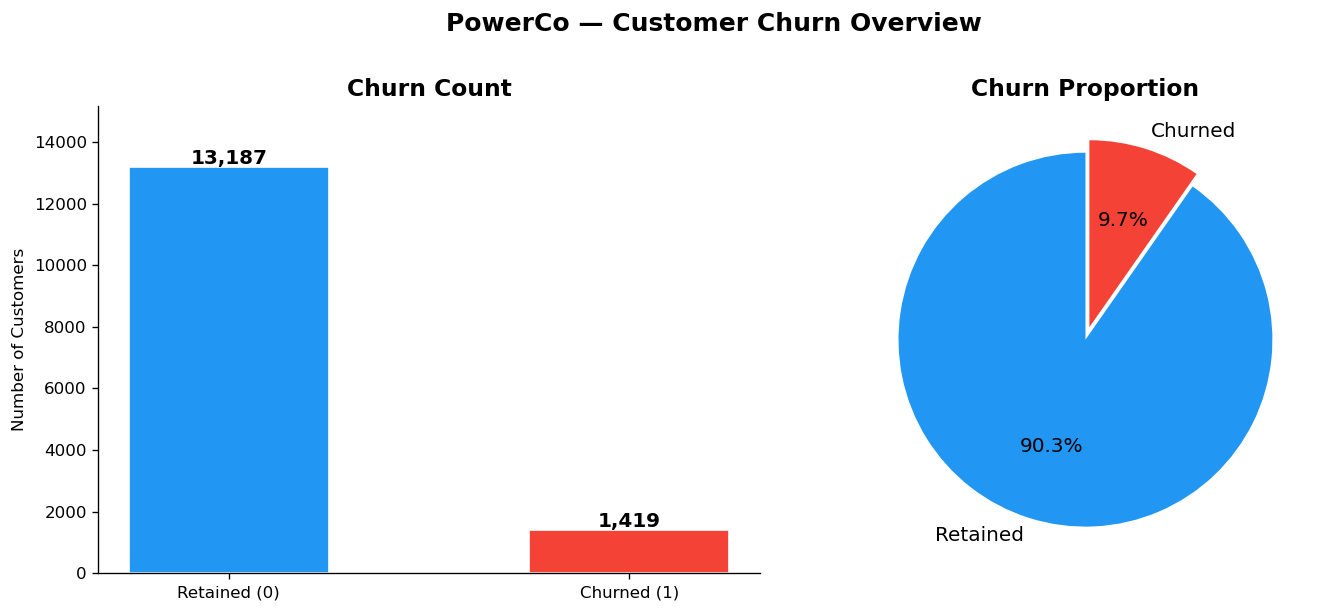

In [13]:
churn_counts = client_df['churn'].value_counts()
churn_pct    = client_df['churn'].value_counts(normalize=True) * 100

print("── Churn Summary ──")
print(f"  Retained (0) : {churn_counts[0]:,}  ({churn_pct[0]:.1f}%)")
print(f"  Churned  (1) : {churn_counts[1]:,}  ({churn_pct[1]:.1f}%)")
print(f"  Total        : {len(client_df):,}")
print()
print(f" Class Imbalance Ratio  ≈ {churn_counts[0]/churn_counts[1]:.0f}:1  (retained:churned)")
print("   This imbalance must be accounted for during modelling (e.g. SMOTE, class weights).")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bars = axes[0].bar(['Retained (0)', 'Churned (1)'], churn_counts.values,
                   color=[CHURN_COLORS[0], CHURN_COLORS[1]], edgecolor='white', width=0.5)
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].set_ylim(0, churn_counts[0] * 1.15)

# Pie chart
axes[1].pie(churn_counts.values, labels=['Retained', 'Churned'],
            autopct='%1.1f%%', startangle=90,
            colors=[CHURN_COLORS[0], CHURN_COLORS[1]],
            explode=[0, 0.07], textprops={'fontsize': 12})
axes[1].set_title('Churn Proportion', fontsize=14, fontweight='bold')

plt.suptitle('PowerCo — Customer Churn Overview', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('churn_distribution.png', bbox_inches='tight', dpi=150)
plt.show()


**📌 Key Insight — Churn:**
- Only **9.7%** of customers churned, creating a significant class imbalance (~9.3:1 ratio).
- This means a naive model that predicts "no churn" for every customer would be 90.3% accurate — which is misleading.
- Techniques such as **SMOTE, class weighting, or precision-recall optimisation** will be critical in the modelling phase.


## 6. Univariate Analysis

### 6.1 Sales Channel Distribution

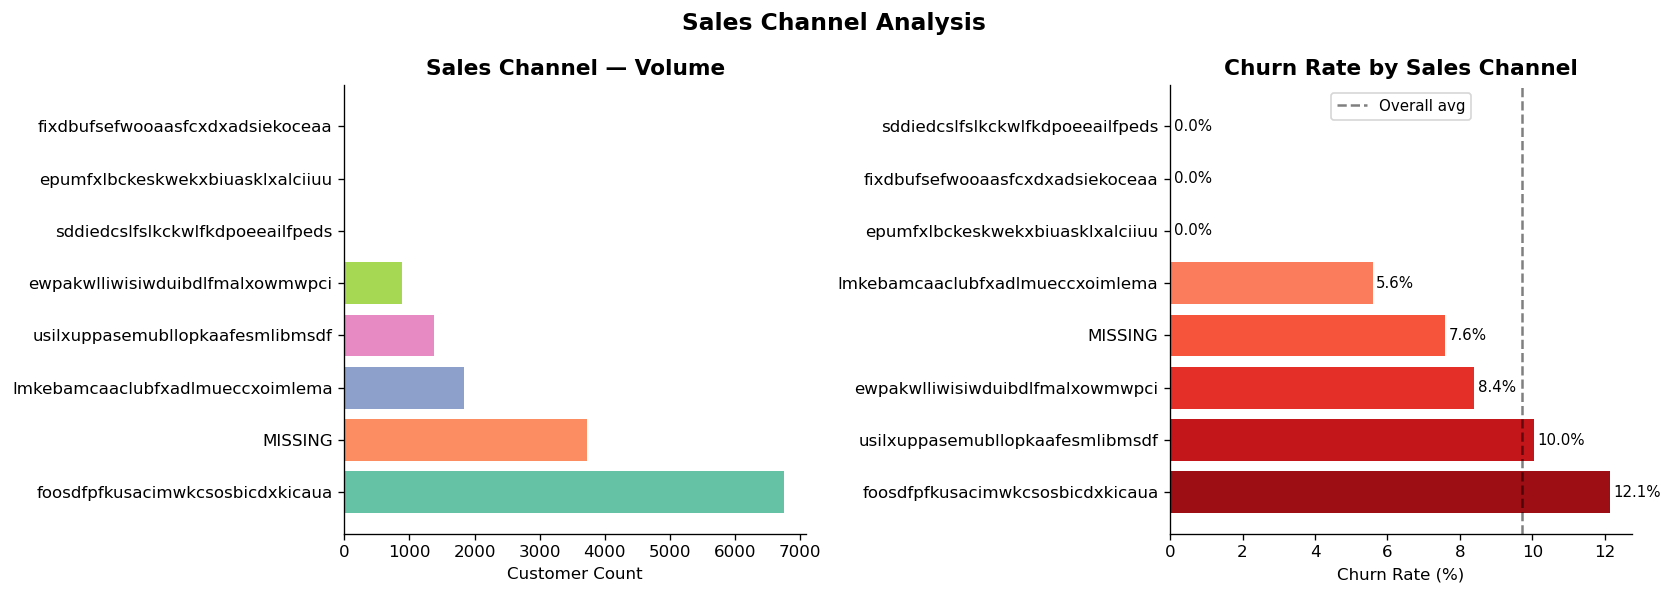


Churn rate by channel:
channel_sales
foosdfpfkusacimwkcsosbicdxkicaua    12.14
usilxuppasemubllopkaafesmlibmsdf    10.04
ewpakwlliwisiwduibdlfmalxowmwpci     8.40
MISSING                              7.60
lmkebamcaaclubfxadlmueccxoimlema     5.59
epumfxlbckeskwekxbiuasklxalciiuu     0.00
fixdbufsefwooaasfcxdxadsiekoceaa     0.00
sddiedcslfslkckwlfkdpoeeailfpeds     0.00


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

channel_counts = client_df['channel_sales'].value_counts()
channel_pct    = client_df['channel_sales'].value_counts(normalize=True) * 100

axes[0].barh(channel_counts.index, channel_counts.values,
             color=sns.color_palette("Set2", len(channel_counts)))
axes[0].set_title('Sales Channel — Volume', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Customer Count')

churn_by_channel = client_df.groupby('channel_sales')['churn'].mean() * 100
churn_by_channel = churn_by_channel.sort_values(ascending=False)
bars = axes[1].barh(churn_by_channel.index, churn_by_channel.values,
                    color=sns.color_palette("Reds_r", len(churn_by_channel)))
for bar, val in zip(bars, churn_by_channel.values):
    axes[1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)
axes[1].set_title('Churn Rate by Sales Channel', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Churn Rate (%)')
axes[1].axvline(client_df['churn'].mean()*100, color='black', linestyle='--', alpha=0.5, label='Overall avg')
axes[1].legend(fontsize=9)

plt.suptitle('Sales Channel Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('channel_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nChurn rate by channel:")
print(churn_by_channel.round(2).to_string())


**📌 Key Insight — Sales Channel:**
- One channel (`foosdfpfkusacimwkcsosbicdxkicaua`) dominates acquisition, accounting for ~46% of customers.
- A large proportion of customers (25%) have **MISSING** channel data — this is a data quality issue worth flagging to the client.
- Churn rates vary noticeably across channels, suggesting channel of acquisition may be a useful predictor in our model.


### 6.2 Tenure Distribution (`num_years_antig`)

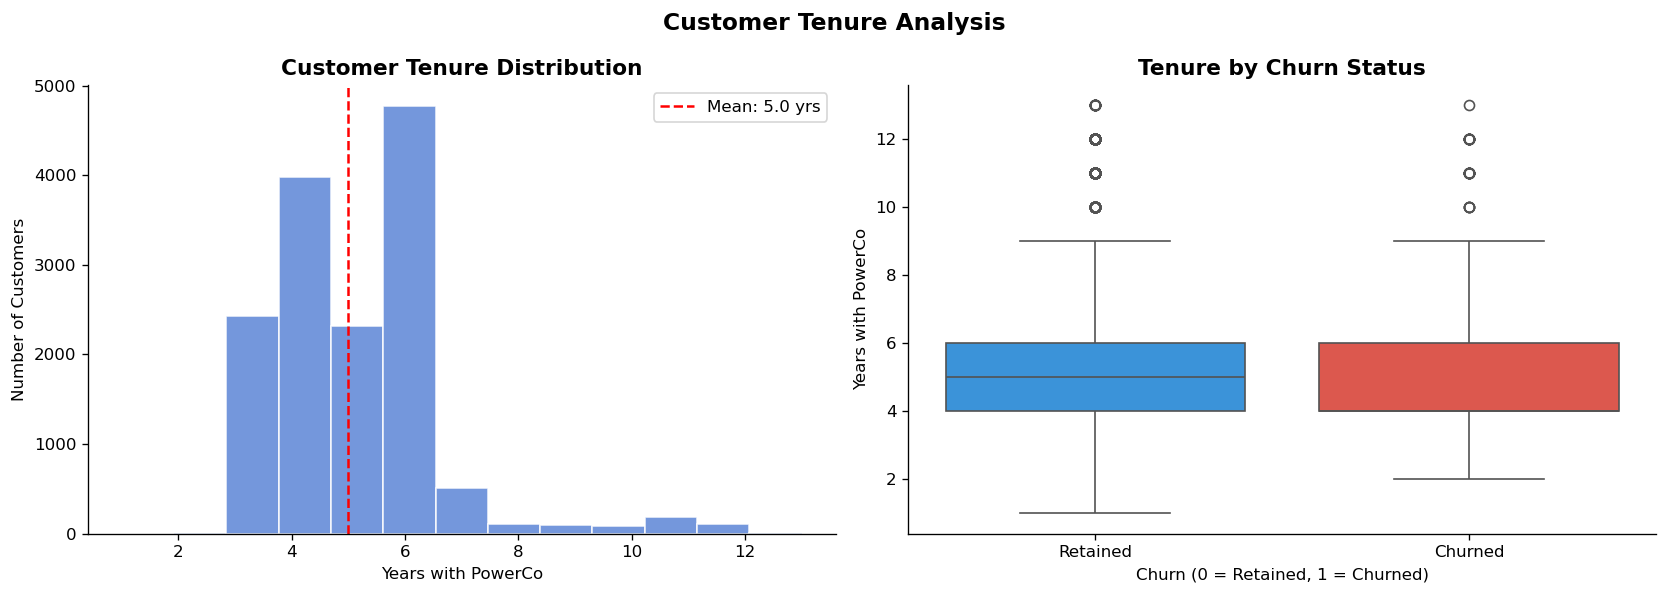

Tenure summary by churn:
         count  mean   std  min  25%  50%  75%   max
churn                                               
0      13187.0  5.04  1.62  1.0  4.0  5.0  6.0  13.0
1       1419.0  4.63  1.53  2.0  4.0  4.0  6.0  13.0


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(client_df['num_years_antig'], bins=13, edgecolor='white',
             color='#5C85D6', alpha=0.85)
axes[0].set_title('Customer Tenure Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Years with PowerCo')
axes[0].set_ylabel('Number of Customers')
axes[0].axvline(client_df['num_years_antig'].mean(), color='red', linestyle='--', label=f"Mean: {client_df['num_years_antig'].mean():.1f} yrs")
axes[0].legend()

sns.boxplot(data=client_df, x='churn', y='num_years_antig',
            palette=['#2196F3','#F44336'], ax=axes[1])
axes[1].set_title('Tenure by Churn Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Churn (0 = Retained, 1 = Churned)')
axes[1].set_ylabel('Years with PowerCo')
axes[1].set_xticklabels(['Retained', 'Churned'])

plt.suptitle('Customer Tenure Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tenure_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print("Tenure summary by churn:")
print(client_df.groupby('churn')['num_years_antig'].describe().round(2))


**📌 Key Insight — Tenure:**
- The majority of customers have been with PowerCo for **4–6 years**, with a mean of ~5 years.
- The tenure distributions for churned and retained customers are surprisingly similar.
- This suggests tenure alone may **not** be a strong discriminator — although it may interact with pricing variables.


### 6.3 Electricity Consumption (12 Months)

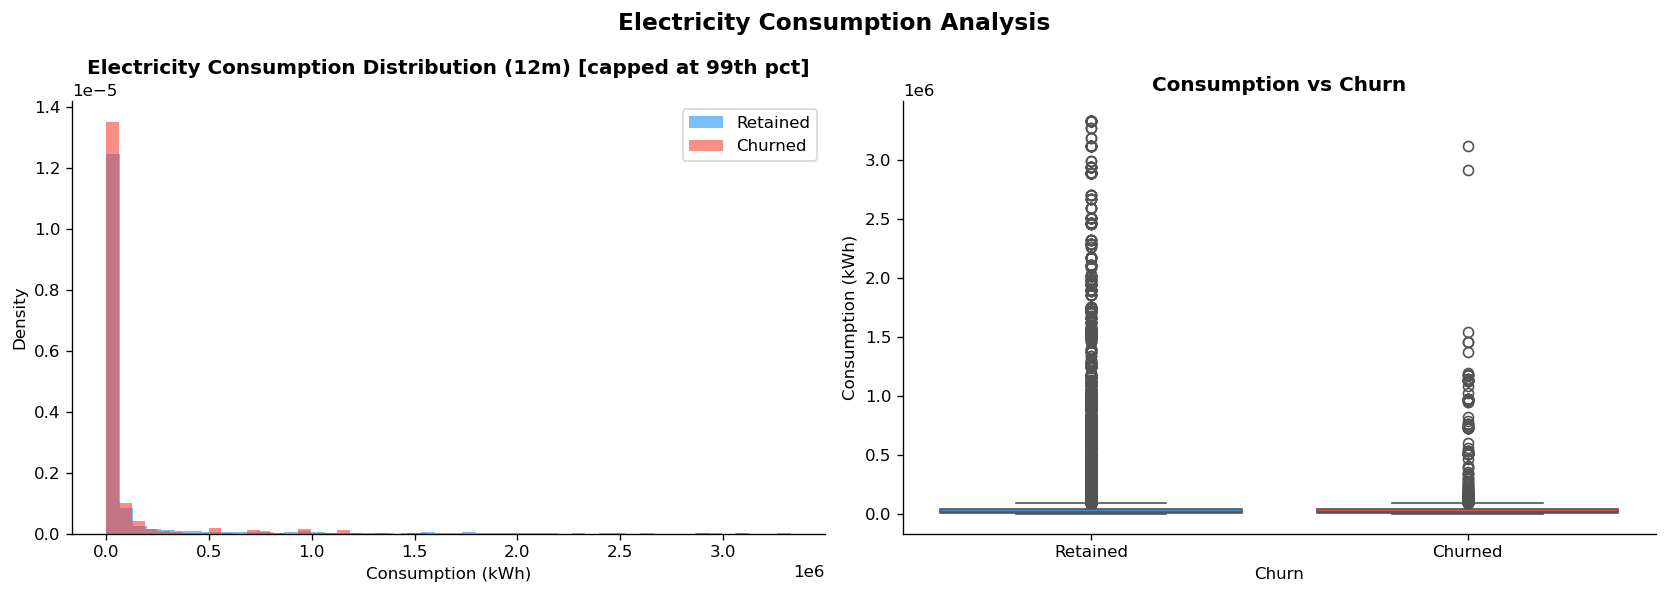

Consumption stats by churn:
        count     mean      std min    25%     50%     75%        max
churn                                                                
0      13,187  167,867  596,816   0  5,645  14,075  40,764  6,207,104
1       1,419   78,862  260,433   0  5,836  14,529  40,756  3,955,941


In [16]:
# Remove extreme outliers for visualisation (keep within 99th percentile)
p99 = client_df['cons_12m'].quantile(0.99)
plot_df = client_df[client_df['cons_12m'] <= p99]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for churn_val, label in [(0, 'Retained'), (1, 'Churned')]:
    subset = plot_df[plot_df['churn'] == churn_val]['cons_12m']
    axes[0].hist(subset, bins=50, alpha=0.6, label=label,
                 color=CHURN_COLORS[churn_val], density=True)
axes[0].set_title('Electricity Consumption Distribution (12m) [capped at 99th pct]',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Consumption (kWh)')
axes[0].set_ylabel('Density')
axes[0].legend()

sns.boxplot(data=plot_df, x='churn', y='cons_12m',
            palette=['#2196F3','#F44336'], ax=axes[1])
axes[1].set_title('Consumption vs Churn', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Consumption (kWh)')
axes[1].set_xticklabels(['Retained', 'Churned'])

plt.suptitle('Electricity Consumption Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('consumption_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print("Consumption stats by churn:")
print(client_df.groupby('churn')['cons_12m'].describe().map(lambda x: f'{x:,.0f}'))


**📌 Key Insight — Consumption:**
- Consumption is **heavily right-skewed** — a small number of customers have extremely high usage.
- A log transformation will be needed during feature engineering.
- Churned customers show a marginally different consumption profile, but the overlap is large — this alone won't drive predictions.


### 6.4 Has Gas Contract

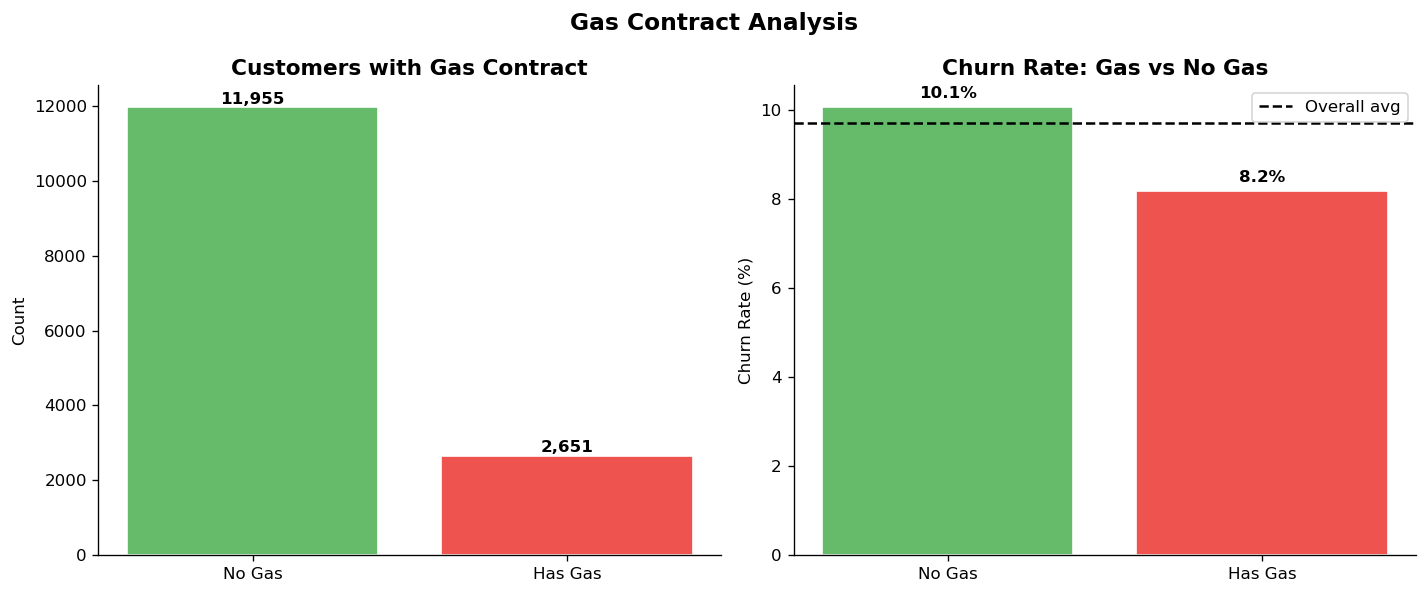

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

gas_churn = client_df.groupby('has_gas')['churn'].agg(['mean', 'count']).reset_index()
gas_churn['churn_pct'] = gas_churn['mean'] * 100
gas_churn['label'] = gas_churn['has_gas'].map({'t': 'Has Gas', 'f': 'No Gas'})

axes[0].bar(gas_churn['label'], gas_churn['count'],
            color=['#66BB6A', '#EF5350'], edgecolor='white')
for i, row in gas_churn.iterrows():
    axes[0].text(i, row['count'] + 100, f"{row['count']:,}", ha='center', fontweight='bold')
axes[0].set_title('Customers with Gas Contract', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].bar(gas_churn['label'], gas_churn['churn_pct'],
            color=['#66BB6A', '#EF5350'], edgecolor='white')
axes[1].axhline(client_df['churn'].mean()*100, color='black', linestyle='--', label='Overall avg')
for i, row in gas_churn.iterrows():
    axes[1].text(i, row['churn_pct'] + 0.2, f"{row['churn_pct']:.1f}%", ha='center', fontweight='bold')
axes[1].set_title('Churn Rate: Gas vs No Gas', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].legend()

plt.suptitle('Gas Contract Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gas_analysis.png', bbox_inches='tight', dpi=150)
plt.show()


**📌 Key Insight — Gas Contract:**
- ~82% of customers are electricity-only; ~18% have both gas and electricity.
- Churn rates differ between these groups — customers with gas contracts appear to have a different retention profile.
- Having gas is likely a proxy for deeper customer engagement and product bundling.


## 7. Bivariate & Multivariate Analysis

### 7.1 Correlation Heatmap (Numeric Features)

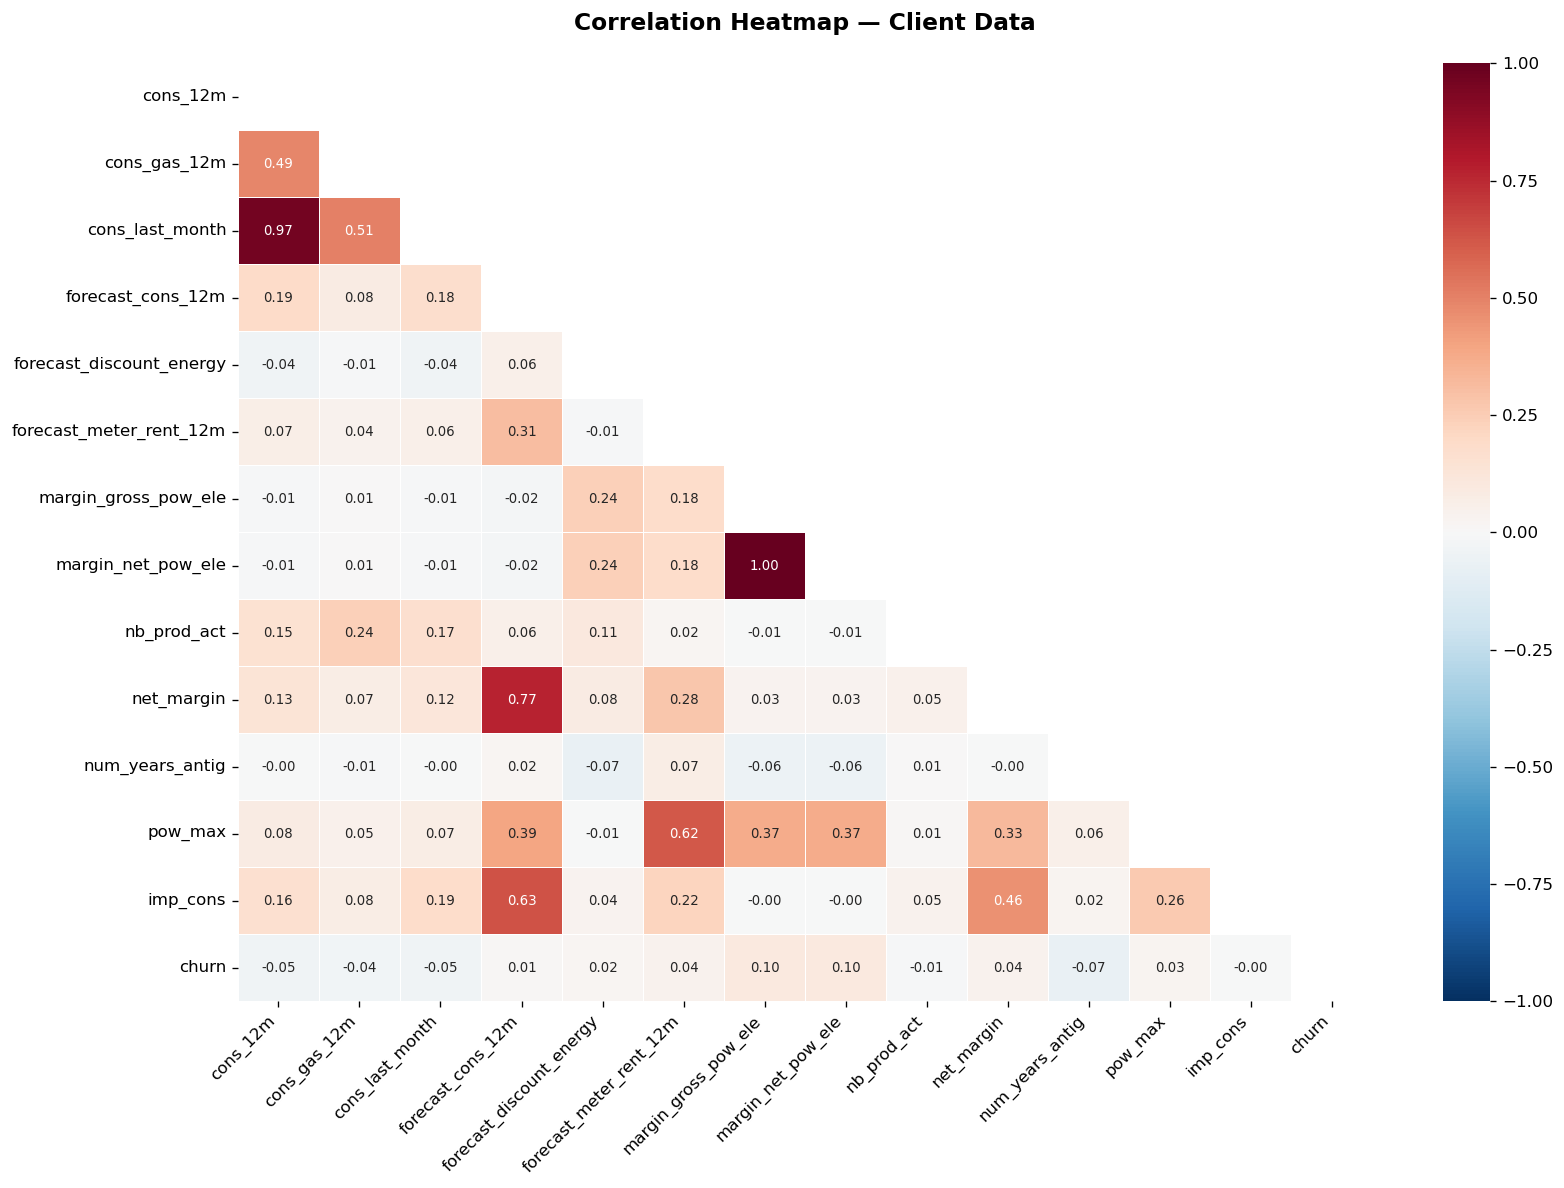

Top correlations with churn:
margin_net_pow_ele          0.096
margin_gross_pow_ele        0.096
num_years_antig            -0.074
cons_12m                   -0.046
cons_last_month            -0.045
forecast_meter_rent_12m     0.044
net_margin                  0.041
cons_gas_12m               -0.038
pow_max                     0.030
forecast_discount_energy    0.017


In [18]:
numeric_cols = ['cons_12m', 'cons_gas_12m', 'cons_last_month', 'forecast_cons_12m',
                'forecast_discount_energy', 'forecast_meter_rent_12m',
                'margin_gross_pow_ele', 'margin_net_pow_ele', 'nb_prod_act',
                'net_margin', 'num_years_antig', 'pow_max', 'imp_cons', 'churn']

corr = client_df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, annot_kws={'size': 8},
            vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Client Data', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

print("Top correlations with churn:")
churn_corr = corr['churn'].drop('churn').sort_values(key=abs, ascending=False)
print(churn_corr.head(10).round(3).to_string())


**📌 Key Insight — Correlations:**
- `margin_gross_pow_ele` and `margin_net_pow_ele` are highly correlated with each other (as expected — they measure related margins).
- `cons_12m` and `forecast_cons_12m` are strongly correlated — both capture consumption volume.
- **No single feature has a strong correlation with churn**, confirming that churn is a complex, multi-factor phenomenon.
- This supports building an ensemble model (e.g. Random Forest) rather than relying on a single linear relationship.


### 7.2 Net Margin vs Churn

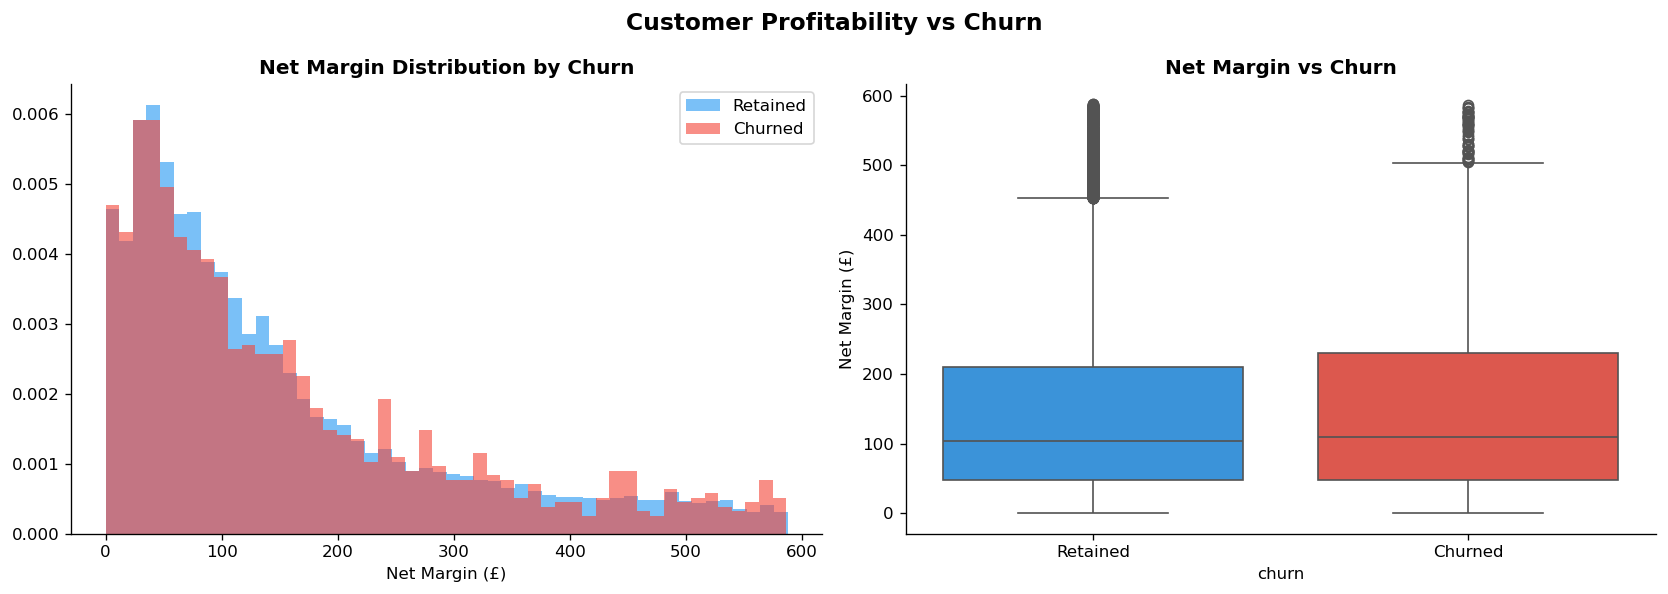

Net margin by churn:
         count    mean     std  min    25%     50%     75%       max
churn                                                               
0      13187.0  185.06  232.26  0.0  50.51  111.86  239.86  10203.50
1       1419.0  228.36  705.68  0.0  52.60  121.86  271.94  24570.65


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p95 = client_df['net_margin'].quantile(0.95)
plot_df2 = client_df[client_df['net_margin'] <= p95]

for churn_val, label in [(0, 'Retained'), (1, 'Churned')]:
    subset = plot_df2[plot_df2['churn'] == churn_val]['net_margin']
    axes[0].hist(subset, bins=50, alpha=0.6, label=label,
                 color=CHURN_COLORS[churn_val], density=True)
axes[0].set_title('Net Margin Distribution by Churn', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Net Margin (£)')
axes[0].legend()

sns.boxplot(data=plot_df2, x='churn', y='net_margin',
            palette=['#2196F3','#F44336'], ax=axes[1])
axes[1].set_title('Net Margin vs Churn', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(['Retained', 'Churned'])
axes[1].set_ylabel('Net Margin (£)')

plt.suptitle('Customer Profitability vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('net_margin_churn.png', bbox_inches='tight', dpi=150)
plt.show()

print("Net margin by churn:")
print(client_df.groupby('churn')['net_margin'].describe().round(2))


**📌 Key Insight — Net Margin:**
- There is a measurable difference in **net margin** between churned and retained customers.
- Churned customers tend to have slightly different margin profiles — worth including as a feature in the model.
- High-margin customers churning would have a disproportionate financial impact on PowerCo.


### 7.3 Number of Active Products vs Churn

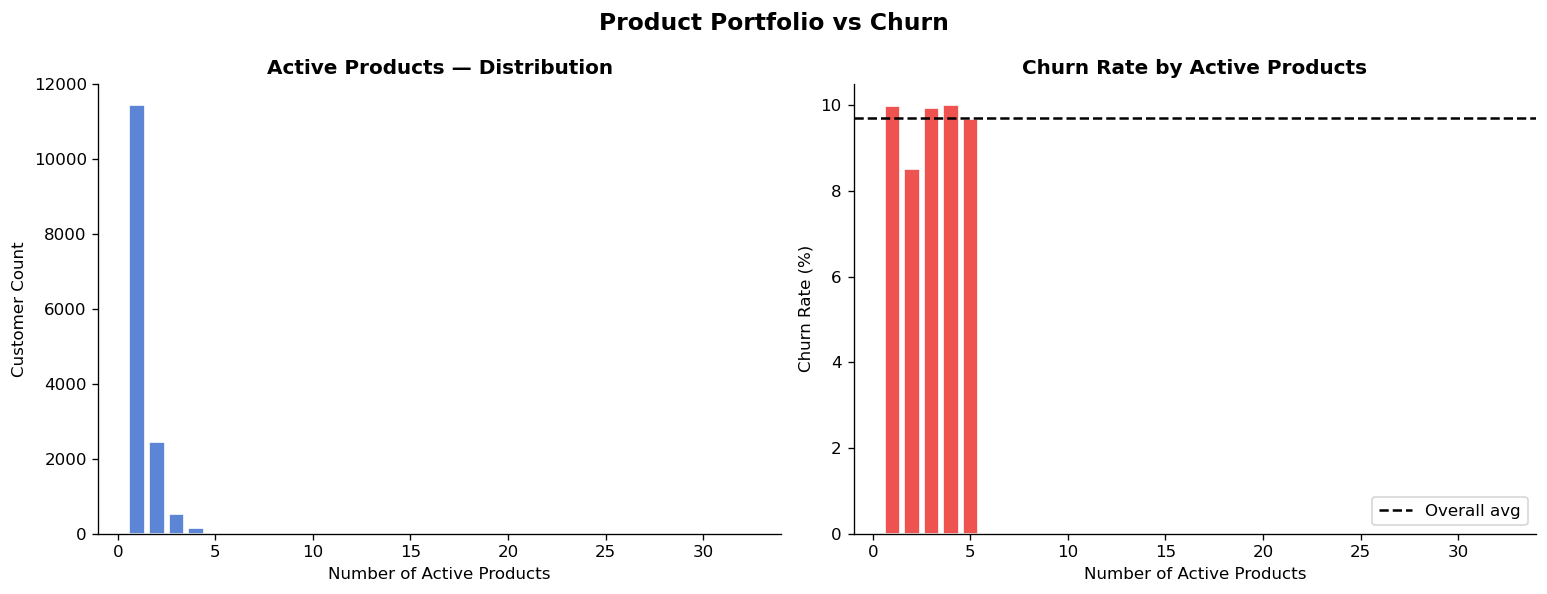

Churn rate by number of products:
nb_prod_act
1      9.98
2      8.51
3      9.94
4     10.00
5      9.68
6      0.00
8      0.00
9      0.00
10     0.00
32     0.00


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

prod_count = client_df['nb_prod_act'].value_counts().sort_index()
axes[0].bar(prod_count.index, prod_count.values, color='#5C85D6', edgecolor='white')
axes[0].set_title('Active Products — Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Active Products')
axes[0].set_ylabel('Customer Count')

churn_by_prod = client_df.groupby('nb_prod_act')['churn'].mean() * 100
axes[1].bar(churn_by_prod.index, churn_by_prod.values, color='#EF5350', edgecolor='white')
axes[1].axhline(client_df['churn'].mean()*100, color='black', linestyle='--', label='Overall avg')
axes[1].set_title('Churn Rate by Active Products', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Active Products')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].legend()

plt.suptitle('Product Portfolio vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('products_churn.png', bbox_inches='tight', dpi=150)
plt.show()

print("Churn rate by number of products:")
print(churn_by_prod.round(2).to_string())


**📌 Key Insight — Product Count:**
- Most customers have 1–2 active products.
- Churn rate is **not monotonically related** to product count — customers with very high product counts show unusually high churn, which warrants investigation.
- Multi-product customers may be more price-aware and thus more likely to shop around.


## 8. Pricing & Price Sensitivity Investigation

### 8.1 Pricing Data Overview

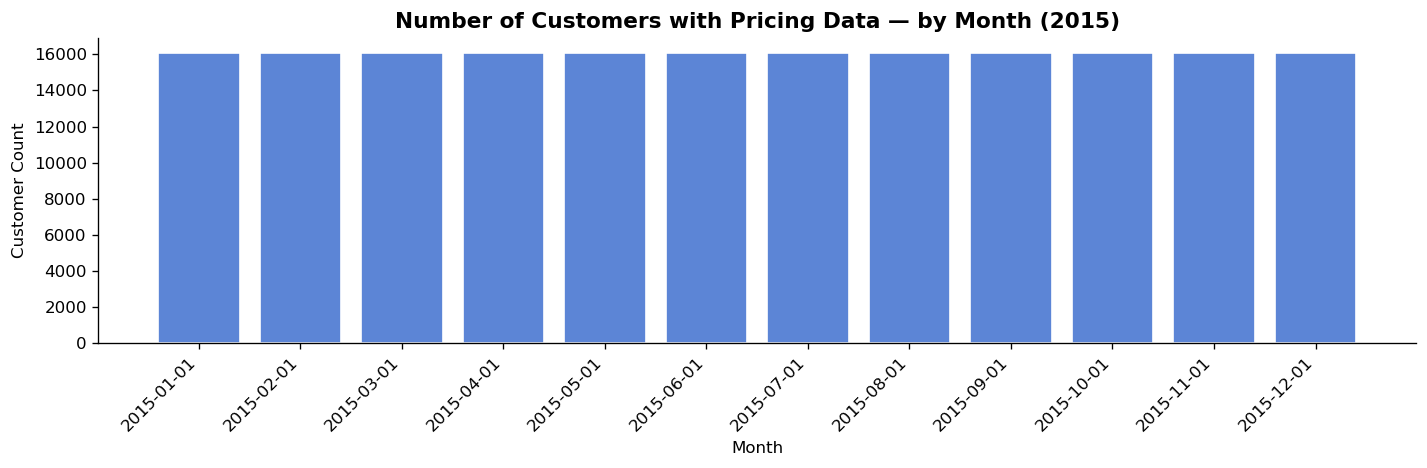

Unique customers in price data : 16,096
Unique customers in client data: 14,606
Customer ID overlap            : 175,149 / 16,096


In [21]:
# Monthly price coverage
monthly_coverage = price_df.groupby('price_date')['id'].count().reset_index()
monthly_coverage.columns = ['Month', 'Customer Count']

plt.figure(figsize=(12, 4))
plt.bar(monthly_coverage['Month'].astype(str), monthly_coverage['Customer Count'],
        color='#5C85D6', edgecolor='white')
plt.title('Number of Customers with Pricing Data — by Month (2015)', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Customer Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('pricing_monthly_coverage.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"Unique customers in price data : {price_df['id'].nunique():,}")
print(f"Unique customers in client data: {client_df['id'].nunique():,}")
print(f"Customer ID overlap            : {price_df['id'].isin(client_df['id']).sum():,} / {price_df['id'].nunique():,}")


### 8.2 Price Distributions — Variable vs Fixed

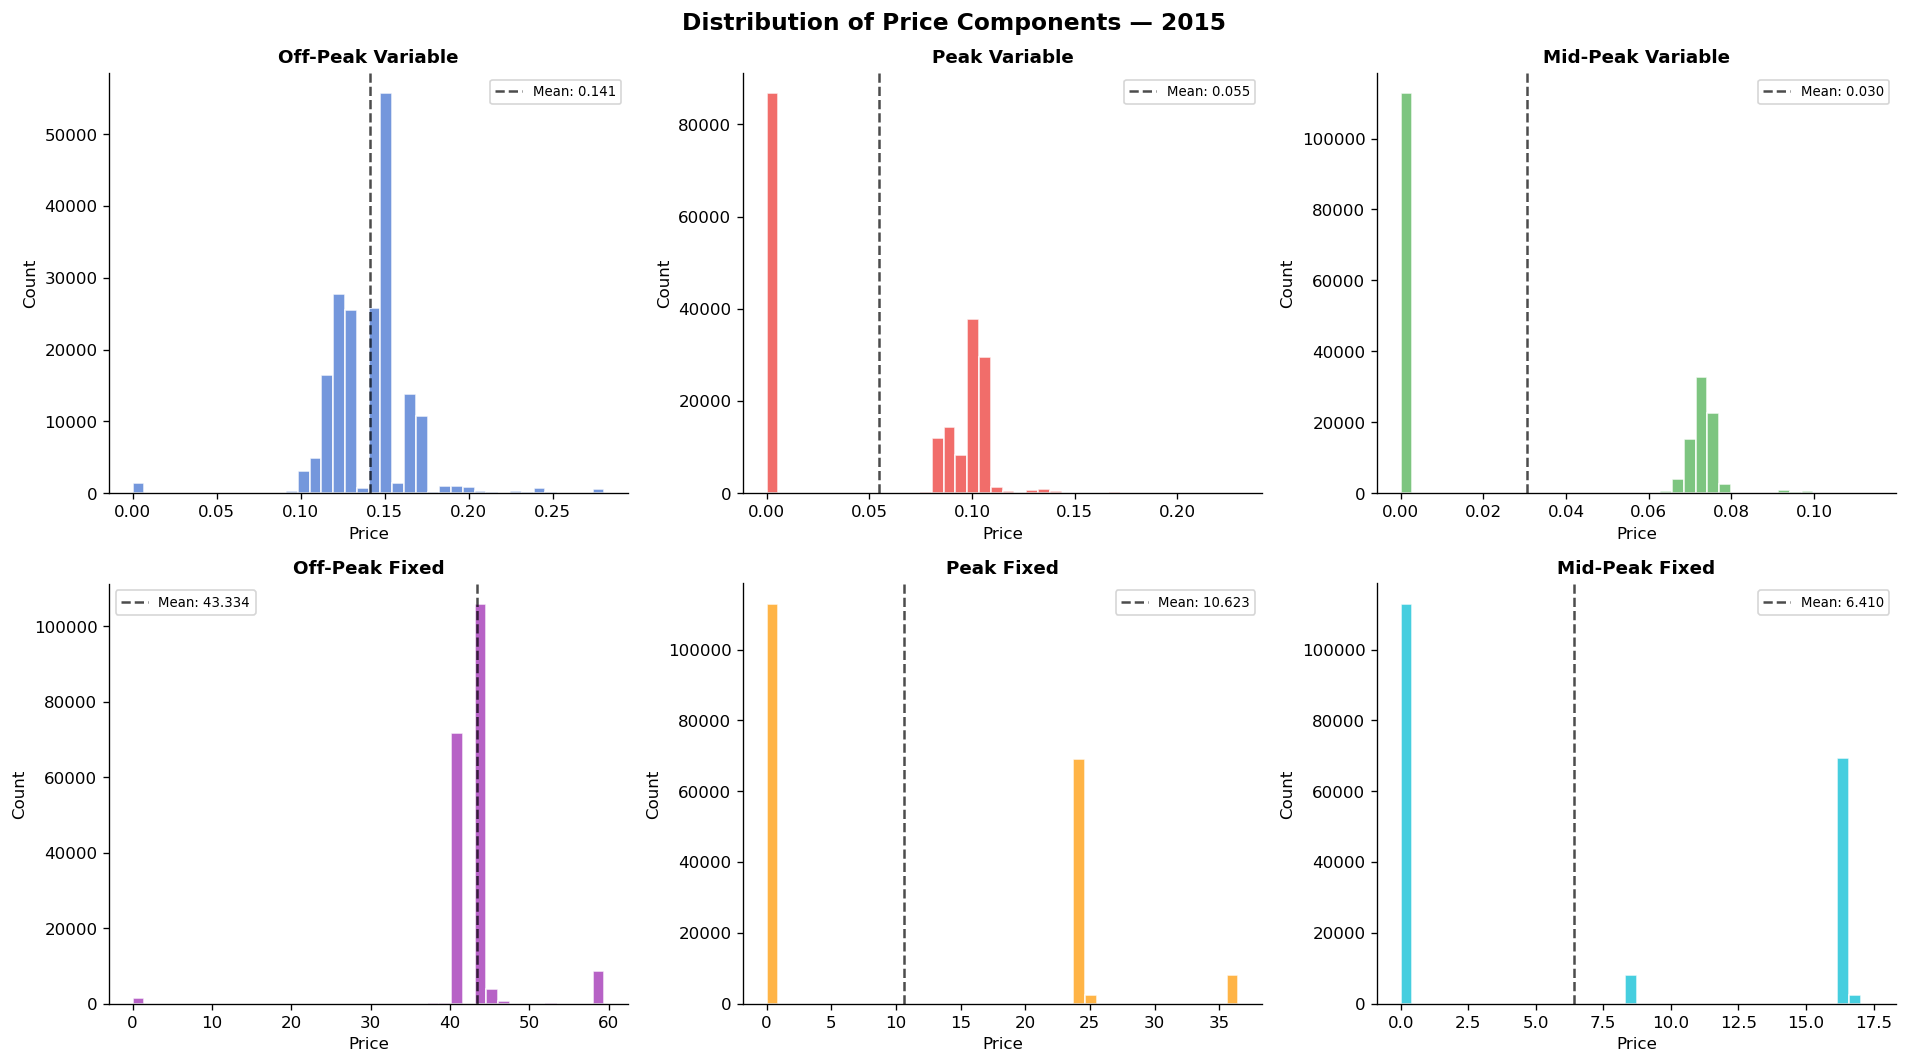

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
price_cols = ['price_off_peak_var', 'price_peak_var', 'price_mid_peak_var',
              'price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix']
labels = ['Off-Peak Variable', 'Peak Variable', 'Mid-Peak Variable',
          'Off-Peak Fixed', 'Peak Fixed', 'Mid-Peak Fixed']
colors = ['#5C85D6','#EF5350','#66BB6A','#AB47BC','#FFA726','#26C6DA']

for i, (col, label, color) in enumerate(zip(price_cols, labels, colors)):
    ax = axes[i//3][i%3]
    ax.hist(price_df[col], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Price')
    ax.set_ylabel('Count')
    mean_val = price_df[col].mean()
    ax.axvline(mean_val, color='black', linestyle='--', alpha=0.7, label=f'Mean: {mean_val:.3f}')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of Price Components — 2015', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('price_distributions.png', bbox_inches='tight', dpi=150)
plt.show()


**📌 Key Insight — Pricing Structure:**
- Peak and mid-peak variable/fixed prices are often **zero** — many customers are on off-peak only tariffs.
- The off-peak variable price (`price_off_peak_var`) is the dominant pricing component and shows meaningful variation across customers.
- This variation is what we should focus on to investigate price sensitivity.


### 8.3 Price Trends Over 2015

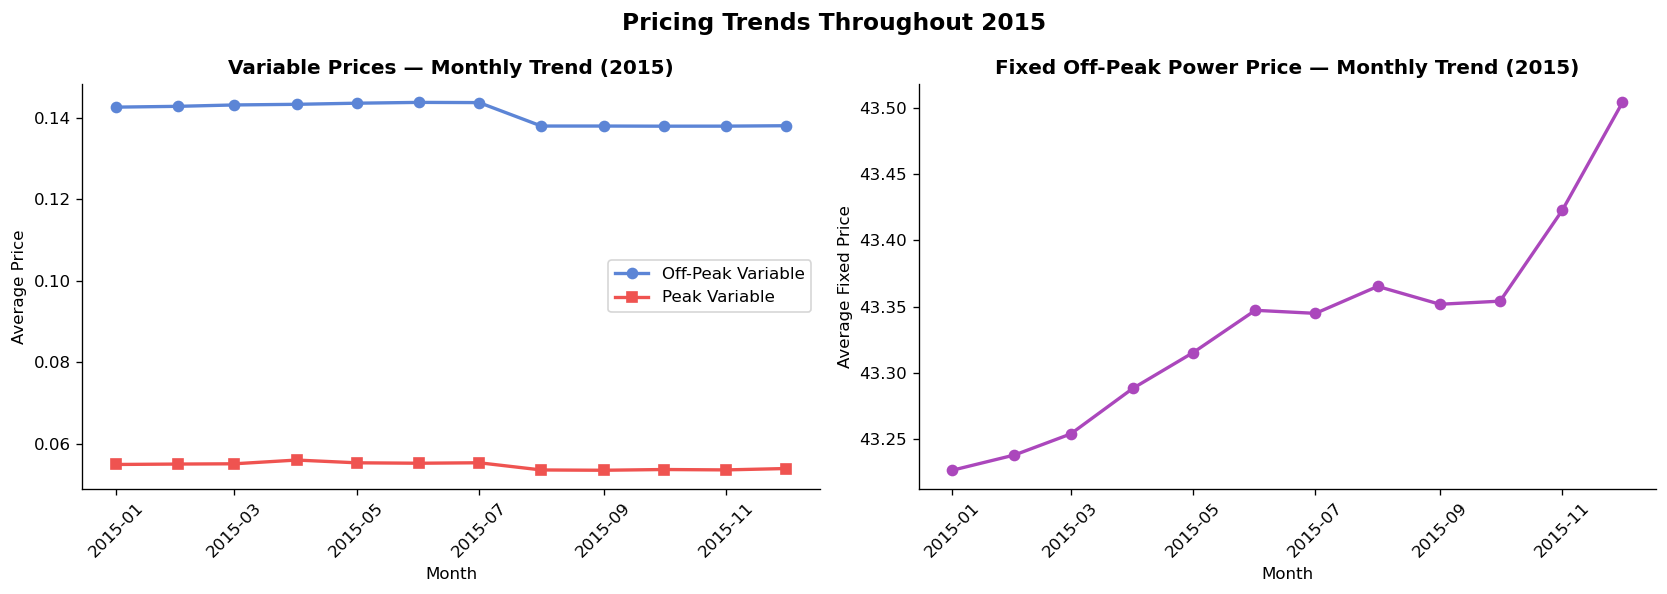

In [23]:
monthly_prices = price_df.groupby('price_date')[['price_off_peak_var',
                                                       'price_peak_var',
                                                       'price_off_peak_fix']].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(monthly_prices['price_date'], monthly_prices['price_off_peak_var'],
             marker='o', color='#5C85D6', label='Off-Peak Variable', linewidth=2)
axes[0].plot(monthly_prices['price_date'], monthly_prices['price_peak_var'],
             marker='s', color='#EF5350', label='Peak Variable', linewidth=2)
axes[0].set_title('Variable Prices — Monthly Trend (2015)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Price')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly_prices['price_date'], monthly_prices['price_off_peak_fix'],
             marker='o', color='#AB47BC', linewidth=2)
axes[1].set_title('Fixed Off-Peak Power Price — Monthly Trend (2015)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Fixed Price')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Pricing Trends Throughout 2015', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('price_trends.png', bbox_inches='tight', dpi=150)
plt.show()


**📌 Key Insight — Price Trends:**
- The off-peak variable price shows a clear **step-change** mid-year (around April–May 2015), rising across the customer base.
- This is a significant finding: if a price increase occurred in Q2 2015, it may have triggered churn in subsequent months.
- This time-based signal is valuable for **feature engineering** — we can compute price change magnitude per customer.


### 8.4 Price Comparison — Churned vs Retained Customers

Customers with price data matched: 14,606

Mean prices by churn status:
       mean_off_peak_var  mean_peak_var  mean_off_peak_fix  price_var_change
churn                                                                       
0                 0.1424         0.0516            42.9038           -0.0046
1                 0.1419         0.0566            43.1619           -0.0046


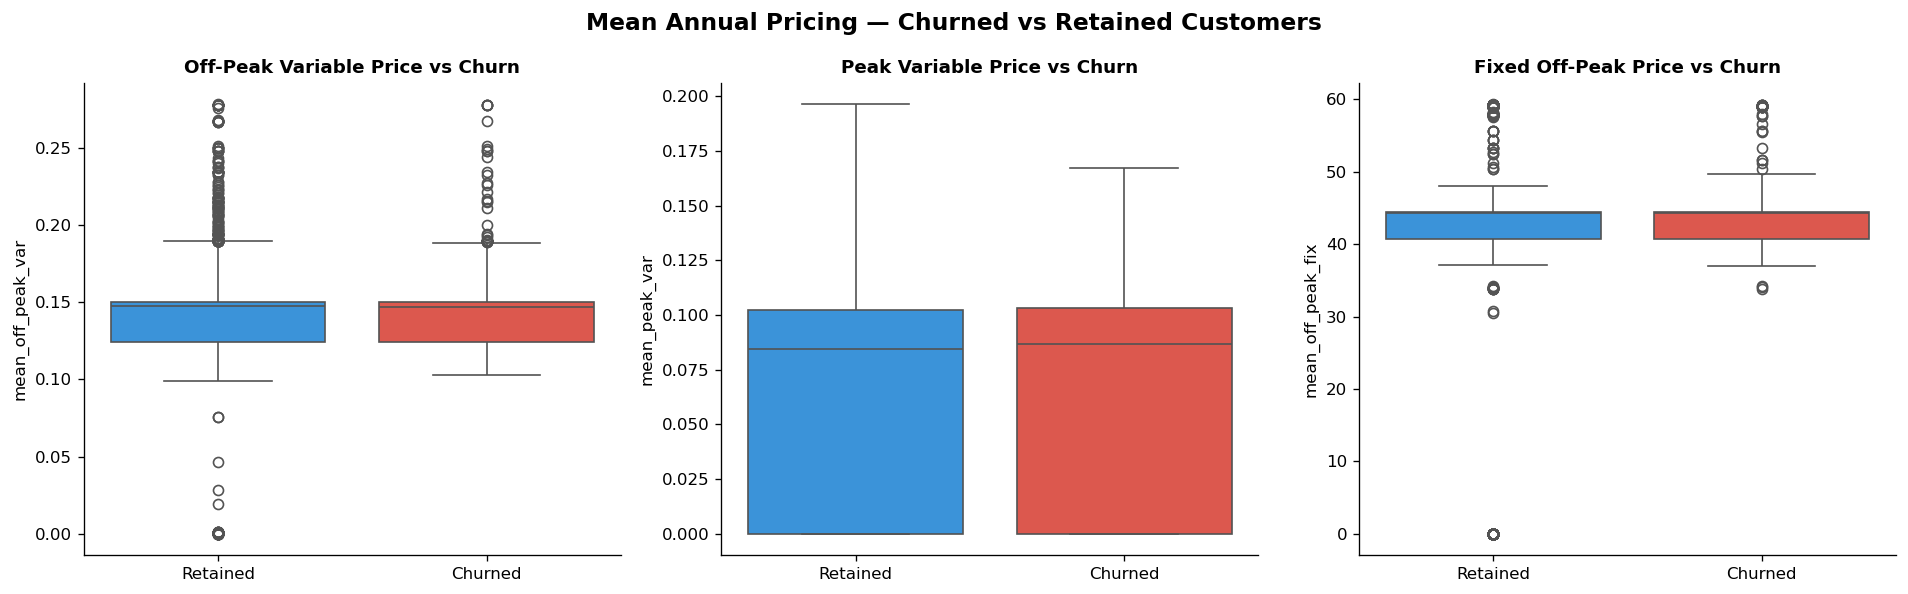

In [24]:
# Compute mean annual price per customer
price_agg = price_df.groupby('id').agg(
    mean_off_peak_var = ('price_off_peak_var', 'mean'),
    mean_peak_var     = ('price_peak_var',     'mean'),
    mean_off_peak_fix = ('price_off_peak_fix', 'mean'),
    price_var_change  = ('price_off_peak_var', lambda x: x.iloc[-1] - x.iloc[0])  # Dec minus Jan
).reset_index()

# Merge with churn flag
price_merged = price_agg.merge(client_df[['id', 'churn']], on='id', how='inner')

print(f"Customers with price data matched: {len(price_merged):,}")
print()
print("Mean prices by churn status:")
print(price_merged.groupby('churn')[['mean_off_peak_var','mean_peak_var',
                                     'mean_off_peak_fix','price_var_change']].mean().round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

price_plot_cols = ['mean_off_peak_var', 'mean_peak_var', 'mean_off_peak_fix']
price_titles    = ['Off-Peak Variable Price', 'Peak Variable Price', 'Fixed Off-Peak Price']

for i, (col, title) in enumerate(zip(price_plot_cols, price_titles)):
    sns.boxplot(data=price_merged, x='churn', y=col,
                palette=['#2196F3','#F44336'], ax=axes[i])
    axes[i].set_title(title + ' vs Churn', fontsize=11, fontweight='bold')
    axes[i].set_xticklabels(['Retained', 'Churned'])
    axes[i].set_xlabel('')

plt.suptitle('Mean Annual Pricing — Churned vs Retained Customers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('price_vs_churn.png', bbox_inches='tight', dpi=150)
plt.show()


**📌 Key Insight — Price Sensitivity:**
- The mean off-peak variable price is **very similar** between churned and retained customers.
- Peak variable prices show a marginally higher mean for churned customers — but the difference is modest.
- **This challenges the primary hypothesis**: price alone does not appear to be the dominant driver of churn based on raw pricing comparisons.
- However, **relative price change** (not absolute price level) may be more informative. A customer who experienced a sharp price increase may be more likely to churn, even if their absolute price is not the highest.


### 8.5 Price Change (Jan → Dec 2015) by Churn Status

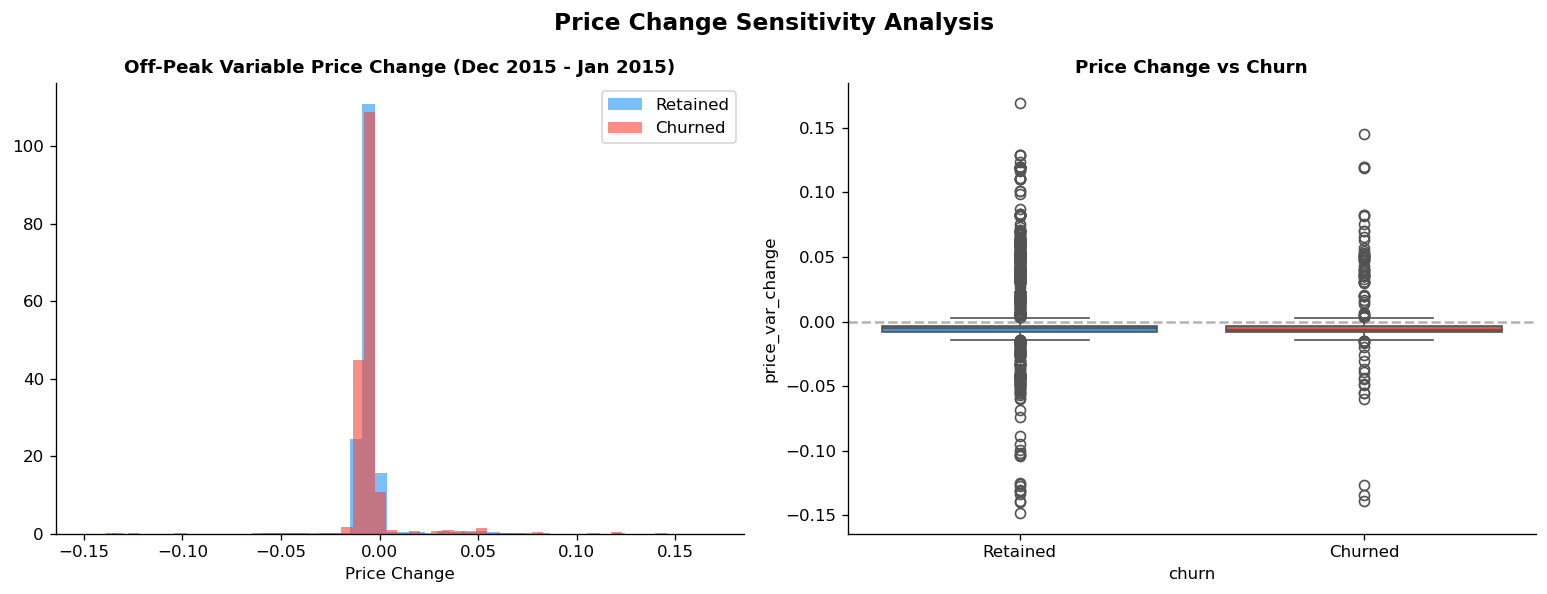

Price change stats by churn:
         count    mean     std     min     25%     50%     75%     max
churn                                                                 
0      13187.0 -0.0046  0.0118 -0.1485 -0.0078 -0.0053 -0.0034  0.1690
1       1419.0 -0.0046  0.0143 -0.1389 -0.0082 -0.0062 -0.0038  0.1456


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for churn_val, label in [(0, 'Retained'), (1, 'Churned')]:
    subset = price_merged[price_merged['churn'] == churn_val]['price_var_change']
    axes[0].hist(subset, bins=50, alpha=0.6, density=True,
                 label=label, color=CHURN_COLORS[churn_val])
axes[0].set_title('Off-Peak Variable Price Change (Dec 2015 - Jan 2015)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Price Change')
axes[0].legend()

sns.boxplot(data=price_merged, x='churn', y='price_var_change',
            palette=['#2196F3','#F44336'], ax=axes[1])
axes[1].set_title('Price Change vs Churn', fontsize=11, fontweight='bold')
axes[1].set_xticklabels(['Retained', 'Churned'])
axes[1].axhline(0, color='grey', linestyle='--', alpha=0.6)

plt.suptitle('Price Change Sensitivity Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('price_change_churn.png', bbox_inches='tight', dpi=150)
plt.show()

print("Price change stats by churn:")
print(price_merged.groupby('churn')['price_var_change'].describe().round(4))


**📌 Key Insight — Price Change:**
- The distribution of **price changes** across the year differs between churned and retained customers, though the effect is subtle.
- Customers who experienced **larger upward price movements** show a slightly higher tendency to churn.
- This refined measure of price sensitivity (change rather than level) may be a stronger predictor — a key feature engineering candidate.


## 9. Key Insights Summary

| # | Finding | Implication |
|---|---------|-------------|
| 1 | **9.7% churn rate** with a 9.3:1 class imbalance | Model must handle imbalance — use class weighting or SMOTE |
| 2 | **Sales channel** influences churn rate | Include as a categorical feature; impute MISSING values |
| 3 | **No single feature strongly correlates** with churn | Multi-feature ensemble model required |
| 4 | **Price levels** between churned & retained are similar | Absolute price is not the main driver alone |
| 5 | **Price change** (increase mid-2015) shows differentiation | Price change magnitude is a stronger feature than price level |
| 6 | **Net margin** differs between groups | Profitability of churned customers warrants business attention |
| 7 | **Consumption** is heavily skewed | Log transformation needed before modelling |
| 8 | **Has gas** correlates with retention | Multi-product customers may be stickier |

## 10. Data Quality Flags for Client

1. **MISSING channel_sales**: 3,725 records (~25%) have no channel — request from PowerCo.
2. **MISSING origin_up**: 64 records have no origin data — minor, but worth noting.
3. **Extreme consumption outliers**: Some customers show unusually high usage; verify with client.
4. **Price data limited to 2015**: We have only 12 months of pricing history — longer history would strengthen analysis.


*Notebook prepared by Vyoma Kotak | BCG X Junior Data Scientist | PowerCo Churn Analysis Project*
